# Feynman Diagrams for Nonlinear Photonics -- Jalali Lab

Bahram Jalali's lab works on nonlinear fiber-optic processes (Time-Stretch
Dispersive Fourier Transform, supercontinuum generation, photonic time
crystals). The processes that drive these effects -- four-wave mixing (FWM),
second/third harmonic generation, stimulated Raman scattering -- are all
described by **Feynman diagrams**: each vertex is a term in the
chi(2)/chi(3) nonlinear-susceptibility expansion of the polarization.

**Theme: you can only measure change -- and remember it.**
A photodetector counts photons -- it registers |E|^2, a CHANGE in photon
flux. It never reads the absolute phase of the field. Every vertex below
conserves energy (a difference statement: sum of frequencies in = sum of
frequencies out) -- and the one thing no diagram, no detector, ever directly
records is the absolute phase. That's why GS phase retrieval exists: to
reconstruct what intensity measurements alone cannot remember.

Built on `dgs/feynman_diagrams.py` and `dgs/gs_core.py`.

In [1]:
import sys, os
_repo = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _repo not in sys.path:
    sys.path.insert(0, _repo)

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()

from dgs.feynman_diagrams import (
    PROCESSES, energy_conservation_check, diagram_order,
    phase_matching_condition, detector_response,
    measurement_vs_memory_table, feynman_sympy_5,
)
print("Loaded", len(PROCESSES), "nonlinear processes")

Loaded 6 nonlinear processes


## Section 1: The process registry

chi(2) processes (3-photon vertices): SHG, SFG, DFG.
chi(3) processes (4-photon vertices): THG, FWM, SRS.
FWM is the workhorse of Jalali-lab fiber photonics -- it underlies
supercontinuum generation and the chirped-pulse readout used in TS-DFT.

In [2]:
for name, proc in PROCESSES.items():
    print(name + "  (" + proc["susceptibility"] + ", order " + str(proc["order"]) + ")")
    print("  " + proc["description"])
    print("")

SHG  (chi(2), order 2)
  Two pump photons absorbed, one photon at 2*omega emitted

SFG  (chi(2), order 2)
  Two photons of different frequency absorbed, sum-frequency photon emitted

DFG  (chi(2), order 2)
  Pump photon absorbed, signal photon stimulated-emitted, idler photon emitted

THG  (chi(3), order 3)
  Three pump photons absorbed, one photon at 3*omega emitted

FWM  (chi(3), order 3)
  Two pump photons absorbed, signal+idler photon pair emitted (parametric gain -- the fiber-optic process behind supercontinuum generation and TS-DFT chirped-pulse readout)

SRS  (chi(3), order 3)
  Pump photon absorbed and converted to a lower-energy Stokes photon, energy difference deposited as a phonon (vibrational change)



## Section 2: Drawing the diagrams

Each vertex is drawn as a dot with incoming legs (absorbed photons, arrows
pointing IN) and outgoing legs (emitted photons, arrows pointing OUT).
This is the standard time-ordered vertex diagram used in nonlinear optics
texts (Boyd's *Nonlinear Optics*), not a full QED Feynman diagram --
photon legs only, no internal propagators, since each process here is a
single instantaneous vertex.

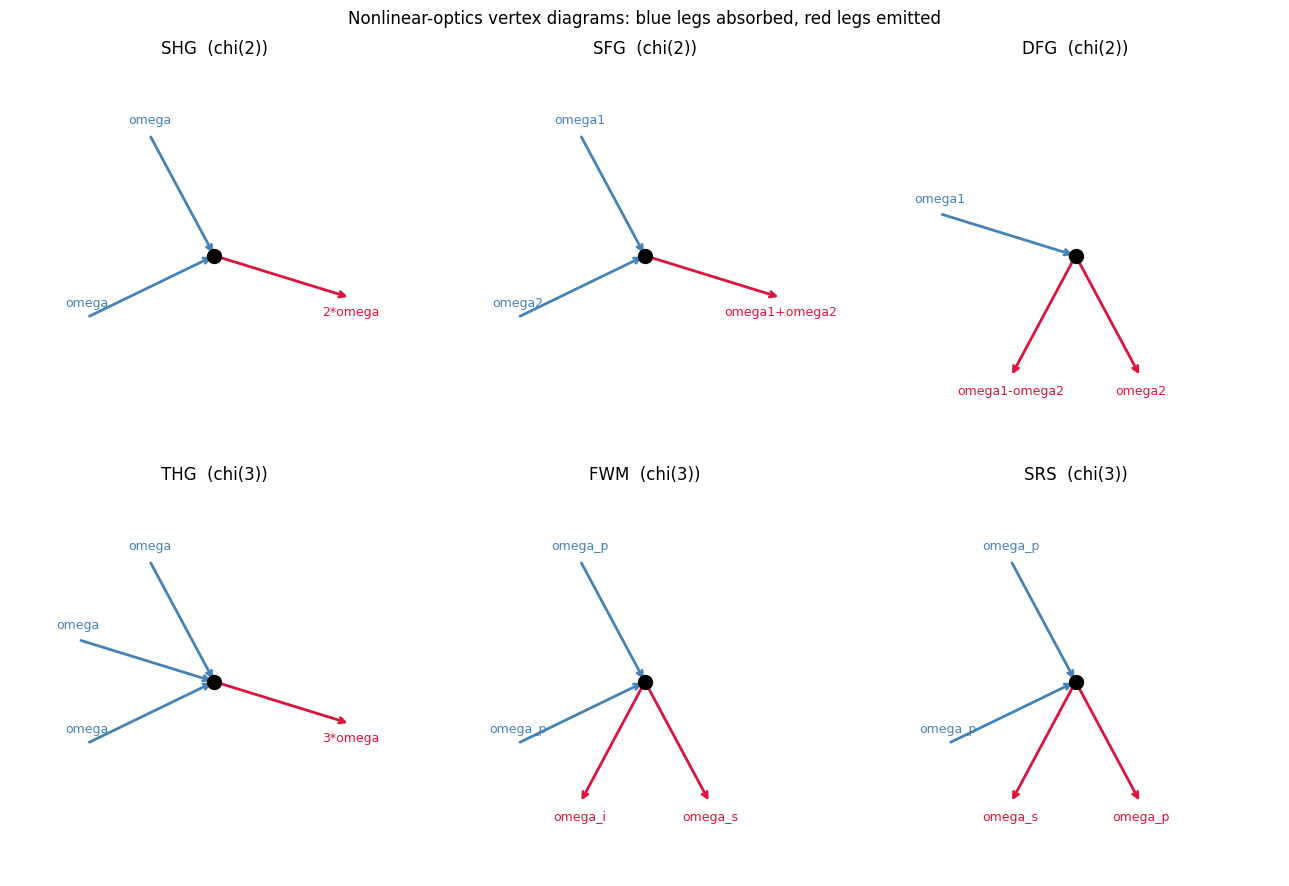

In [3]:
def draw_vertex(ax, process_name):
    proc = PROCESSES[process_name]
    legs = proc["legs"]
    vx, vy = 0.0, 0.0
    ax.plot(vx, vy, 'o', color='black', markersize=10, zorder=5)
    n_in = sum(1 for _, s in legs if s < 0)
    n_out = sum(1 for _, s in legs if s > 0)
    in_i, out_i = 0, 0
    for label, sign in legs:
        if sign < 0:
            angle = np.pi * (0.65 + 0.5 * in_i / max(n_in - 1, 1)) if n_in > 1 else np.pi * 0.9
            in_i += 1
            x0, y0 = vx + 1.4*np.cos(angle), vy + 1.4*np.sin(angle)
            ax.annotate('', xy=(vx, vy), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
            ax.text(x0, y0 + 0.12, label, fontsize=9, ha='center', color='steelblue')
        else:
            angle = -np.pi * (0.35 + 0.3 * out_i / max(n_out - 1, 1)) if n_out > 1 else -np.pi * 0.1
            out_i += 1
            x1, y1 = vx + 1.4*np.cos(angle), vy + 1.4*np.sin(angle)
            ax.annotate('', xy=(x1, y1), xytext=(vx, vy),
                        arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
            ax.text(x1, y1 - 0.18, label, fontsize=9, ha='center', color='crimson')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_title(process_name + '  (' + proc["susceptibility"] + ')')
    ax.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for ax, name in zip(axes.flat, PROCESSES.keys()):
    draw_vertex(ax, name)
plt.suptitle('Nonlinear-optics vertex diagrams: blue legs absorbed, red legs emitted', fontsize=12)
plt.tight_layout()
plt.savefig('feynman_vertices.png', dpi=100)
plt.show()

## Section 3: Energy conservation at each vertex

Energy conservation IS a "change" statement: sum(signed frequencies) = 0.
No vertex has an absolute energy -- only the balance across it matters.

In [4]:
print("=== SHG: omega=1.0 ===")
r = energy_conservation_check("SHG", {"omega": 1.0})
print("  energy change =", round(r["energy_change"], 8), " conserved =", r["conserved"])

print("")
print("=== FWM: omega_p=1.0, omega_s=1.2, omega_i=0.8 (valid combo) ===")
r = energy_conservation_check("FWM", {"omega_p": 1.0, "omega_s": 1.2, "omega_i": 0.8})
print("  energy change =", round(r["energy_change"], 8), " conserved =", r["conserved"])

print("")
print("=== FWM: omega_p=1.0, omega_s=1.5, omega_i=0.8 (INVALID combo) ===")
r = energy_conservation_check("FWM", {"omega_p": 1.0, "omega_s": 1.5, "omega_i": 0.8})
print("  energy change =", round(r["energy_change"], 8), " conserved =", r["conserved"])

=== SHG: omega=1.0 ===
  energy change = 0.0  conserved = True

=== FWM: omega_p=1.0, omega_s=1.2, omega_i=0.8 (valid combo) ===
  energy change = 0.0  conserved = True

=== FWM: omega_p=1.0, omega_s=1.5, omega_i=0.8 (INVALID combo) ===
  energy change = 0.3  conserved = False


## Section 4: Four-wave mixing -- the Jalali-lab process

FWM converts two pump photons into a signal + idler pair:
2*omega_p = omega_s + omega_i. Sweep the signal detuning and verify the
idler frequency the process must produce to conserve energy.

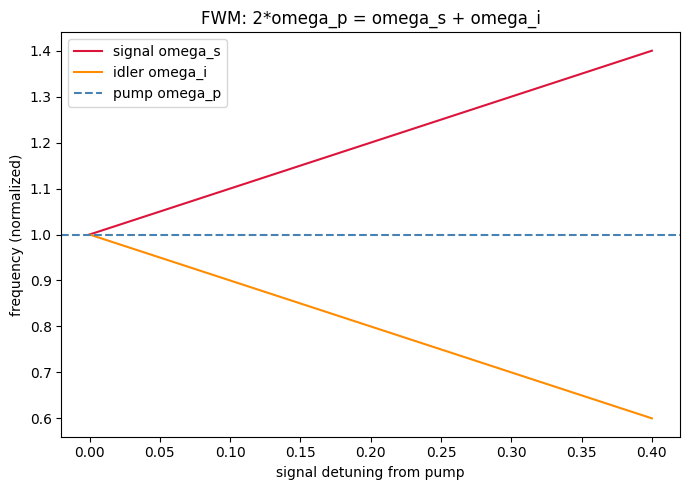

Phase matching condition (k-vector analog):
  Eq(Delta_k, -k1 - k2 + k3 + k4)


In [5]:
omega_p = 1.0
signal_detunings = np.linspace(0.0, 0.4, 50)
omega_s = omega_p + signal_detunings
omega_i = 2*omega_p - omega_s   # energy conservation forces this

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(signal_detunings, omega_s, label='signal omega_s', color='crimson')
ax.plot(signal_detunings, omega_i, label='idler omega_i', color='darkorange')
ax.axhline(omega_p, color='steelblue', linestyle='--', label='pump omega_p')
ax.set_xlabel('signal detuning from pump')
ax.set_ylabel('frequency (normalized)')
ax.set_title('FWM: 2*omega_p = omega_s + omega_i')
ax.legend()
plt.tight_layout()
plt.savefig('fwm_energy_conservation.png', dpi=100)
plt.show()

print("Phase matching condition (k-vector analog):")
print(" ", phase_matching_condition("FWM"))

## Section 5: The detector -- you can only measure change

A photodetector measures |E|^2. The phase of E is thrown away. Plot a
complex field and show what survives the measurement versus what is lost.

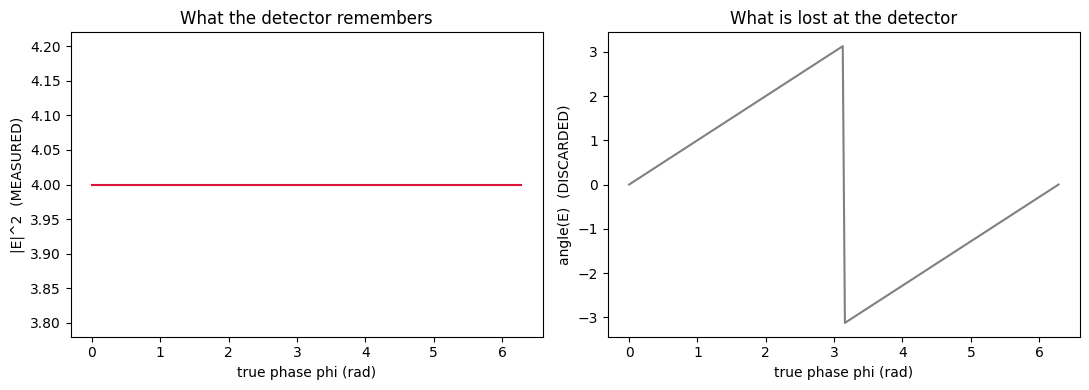

Intensity is flat (|E|=2 always) -- the detector remembers NOTHING about phi.
This is exactly the information GS phase retrieval must reconstruct.


In [6]:
phi_true = np.linspace(0, 2*np.pi, 200)
E = 2.0 * np.exp(1j * phi_true)
dr = detector_response(E)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(phi_true, dr["intensity_measured"], color='crimson')
ax1.set_xlabel('true phase phi (rad)')
ax1.set_ylabel('|E|^2  (MEASURED)')
ax1.set_title('What the detector remembers')

ax2.plot(phi_true, dr["phase_discarded"], color='gray')
ax2.set_xlabel('true phase phi (rad)')
ax2.set_ylabel('angle(E)  (DISCARDED)')
ax2.set_title('What is lost at the detector')
plt.tight_layout()
plt.savefig('detector_change_vs_memory.png', dpi=100)
plt.show()

print("Intensity is flat (|E|=2 always) -- the detector remembers NOTHING about phi.")
print("This is exactly the information GS phase retrieval must reconstruct.")

## Section 6: Measurement vs. memory -- the unifying table

In [7]:
table = measurement_vs_memory_table()
for k, v in table.items():
    if isinstance(v, dict):
        print(k + ":")
        print("  changes:              " + v["changes"])
        print("  measured/remembered:  " + v["measured/remembered"])
        print("")
print("Common lesson:")
print(" ", table["common_lesson"])

Photodetector:
  changes:              photon arrival
  measured/remembered:  intensity |E|^2, not phase

SHG/SFG/DFG vertex:
  changes:              photon energy redistribution
  measured/remembered:  energy conservation Delta(omega)=0

FWM vertex:
  changes:              two pump photons -> signal+idler pair
  measured/remembered:  phase-matching Delta(k)=0

SRS vertex:
  changes:              photon energy -> phonon (vibration)
  measured/remembered:  Stokes shift (the change IS the signal)

GS algorithm:
  changes:              estimate updated each iteration
  measured/remembered:  only intensity constraints |G_k|=sqrt(I_k); phase is inferred, never measured

Common lesson:
  Every device in this list records a DIFFERENCE (energy, intensity, photon number) -- never an absolute, unmeasurable quantity like phase. Algorithms (GS) exist precisely to recover what was never recorded.


## Section 7: Unified symbolic equations

In [8]:
eqs = feynman_sympy_5()
for name, eq in eqs.items():
    print(name + ":")
    display(eq)

SHG_energy_conservation:


FWM_energy_conservation:


Phase_matching:


Detector_intensity:


GS_phase_not_measured:


## Summary

| Process | Order | What changes | What's conserved |
|---|---|---|---|
| SHG/SFG/DFG | chi(2) | photon energy redistribution | sum(omega) |
| FWM | chi(3) | 2 pump -> signal + idler | 2*omega_p = omega_s + omega_i |
| SRS | chi(3) | photon energy -> phonon | Stokes shift IS the signal |
| Photodetector | -- | photon arrival | |E|^2 only, phase lost |
| GS algorithm | -- | estimate updated per iteration | intensity constraints only |

Every nonlinear-optics vertex above is a statement about energy DIFFERENCES.
Every detector measurement is a statement about intensity DIFFERENCES. The
absolute phase is never recorded by any physical process here -- it has to
be reconstructed algorithmically. That reconstruction is the entire point of
`dgs/gs_core.py`.